# Tutorial: Constrained Markov Chain Monte Carlo (MCMC)

This notebook provides a brief tutorial on how to use constrained MCMC samplers within the `QeMCMC` framework. We will demonstrate how to enforce a constraint on the states sampled by both classical and quantum-enhanced MCMC algorithms.

## 1. Set-up and Imports

First, let's import the necessary packages and modules.

In [1]:

import numpy as np
from matplotlib import pyplot as plt
from joblib import Parallel, delayed
from scipy import sparse
import itertools

# Internal imports from our QeMCMC package
from qemcmc.sampler import ClassicalProposal, QeProposal
from qemcmc.sampler.runners import MCMCRunner, ConstrainedMCMCRunner
from qemcmc.utils import plot_chains, get_random_state
from qemcmc.model import EnergyModel, ConstraintModel, ModelMaker

## 2. Define Model Parameters

Next, we define the parameters for our simulation. We'll use an Ising model with `n=10` spins.

In [2]:
n = 10  # Number of spins in the system
n_spins = n
reps = 5  # How many markov chains to produce
steps = 200  # Length of each markov chain
temp = 0.1  # Temperature of the system



Now, let's create the couplings for our Ising model.

In [3]:

# Make baseline Ising gmodel
base_model = ModelMaker(n, "Fully Connected Ising", "Base Ising Model").model


## 3. Define the Constraint

We'll define a constraint function that accepts a bitstring and returns `True` if the constraint is satisfied, and `False` otherwise. In this example, we'll enforce a zero magnetization constraint, which means that the number of '1's (spin up) must be equal to the number of '0's (spin down).

In [4]:


shape_of_J = (n_spins, n_spins)
J_constraint = np.zeros(shape_of_J)
#J_constraint[-2, -1] = 1
#J_constraint[-1, -2] = 1
for i in range(n_spins):
    for j in range(i+1, n_spins):
        u = np.random.uniform(0, 1)
        if u < 0.05:# 10% chance of adding a constraint between these spins
            J_constraint[i, j] = 1
            J_constraint[j, i] = 1
# To ensure non-constant constraint
J_constraint[0,1] = 1
J_constraint[1,0] = 1

def constraint_checker_func(bitstring: str) -> bool:
    """In {0, 1} representation, this constraint means no two adjacent bits can both be 1"""

    sum = 0
    for i in range(len(bitstring)):
        for j in range(i+1, len(bitstring)):
            if bitstring[i] != bitstring[j]:
                sum += J_constraint[i, j]


    return sum == 0

constraint_model = ConstraintModel(n, constraint_couplings = [J_constraint,], couplings = base_model.couplings, name="Constraint Model", cost_function_signs=base_model.cost_function_signs, constraint_func=constraint_checker_func, constraint_signs = [-1,])

Runner = ConstrainedMCMCRunner(constraint_model, temp=temp, reject_invalid=True)




Constraint Couplings:
 [[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]]


C:\Users\Stuart Ferguson\OneDrive - University of Edinburgh\Documents\PhD\CODE\QeMCMC\QeMCMC\src\qemcmc\model\energy_model.py:542: UserWarning: Could not find enough valid initial states satisfying the constraint. Found 54 valid states after 1000 attempts. You may want to provide them manually if more are needed.
  warnings.warn(


## 4. Run Classical MCMC with Constraints

The `ConstrainedMCMCRunner` is used to run an MCMC simulation with a given constraint. It works by proposing a new state and only accepting it if it satisfies the constraint. 

In [5]:
runner = ConstrainedMCMCRunner(constraint_model, temp, constraint_checker_func)

Of course, we still need to provide a mechanism of proposal, before we can run the algorithm by calling runner.run()
### Uniform Proposal

In [6]:
uni_chains = []
uni_rejections = []
for rep in range(reps):
    classical_uniform_MCMC = ClassicalProposal(constraint_model, method="uniform")
    uni_chain, uni_rejection = runner.run(classical_uniform_MCMC, steps, initial_state=constraint_model.initial_state[rep], name="classical uniform MCMC", verbose=False, sample_frequency=1)
    uni_chains.append(uni_chain)
    uni_rejections.append(uni_rejection)


# print average rejections per chain
avg_uni_rejections = np.mean(uni_rejections)/steps
print(f"Average constraint rejections per step: {avg_uni_rejections}")



Average constraint rejections per step: 0.932


### Local Method

In [7]:
loc_chains = []
loc_rejections = []
for rep in range(reps):
    classical_local_MCMC = ClassicalProposal(constraint_model, method="local")
    loc_chain, loc_rejection = runner.run(classical_local_MCMC, steps, initial_state=constraint_model.initial_state[rep], name="classical local MCMC", verbose=False, sample_frequency=1)
    loc_chains.append(loc_chain)
    loc_rejections.append(loc_rejection)

# print average rejections per chain
avg_loc_rejections = np.mean(loc_rejections)/steps
print(f"Average constraint rejections per step: {avg_loc_rejections}")

Average constraint rejections per step: 0.598


## 5. Run Quantum-Enhanced MCMC (QeMCMC) with Constraints

Now we run the quantum-enhanced version, just like in the unconstrained case. The `QeProposal` class is very similar to the `ClassicalProposal` class, but it includes extra parameters specific to the quantum algorithm, like `gamma` and `time`.

In [8]:
# constrained QeMCMC parameters
gamma = (0.2, 0.3)  # Relative strength of mixer hamiltonian
time = (5,10)  # Time for hamiltonian simulation


m_ = 1 # How many subgroups in (optional) coarse graining
coupling_weights_ = [1, 1, 1] # How much weight each hamiltonian term carries
def run_qemcmc(rep, m, coupling_weights):
    quantum_proposal = QeProposal(constraint_model, gamma=gamma, time=time, m = m, coupling_weights = coupling_weights)
    return runner.run(quantum_proposal, steps, initial_state=constraint_model.initial_state[rep], name="QeMCMC", verbose=True, sample_frequency=1)


output  = run_qemcmc(0, m_, coupling_weights_)
qe_chain = output[0]
Qe_rejection = output[1]
print("The proportion of constraint rejections in QeMCMC is: ", Qe_rejection/steps)

Run QeMCMC:   0%|          | 0/200 [00:00<?, ?it/s]

The proportion of constraint rejections in QeMCMC is:  0.24


Lets run some more chains to get some averages

In [9]:

m_ = 1 # How many subgroups in (optional) coarse graining

coupling_weights_ = [1, 1, 1] # How much weight each hamiltonian term carries
# Run in parallel as they can take a while.
output = Parallel(n_jobs=-1)(delayed(run_qemcmc)(rep, m_, coupling_weights_) for rep in range(reps))
#run_qemcmc(0)

output = np.array(output)
qe_chains = output[:, 0]
Qe_rejection = output[:, 1]

# print average rejections per chain
avg_rejections = np.mean(Qe_rejection)/steps
print(f"Average constraint rejections per step: {avg_rejections}")

Average constraint rejections per step: 0.42700000000000005


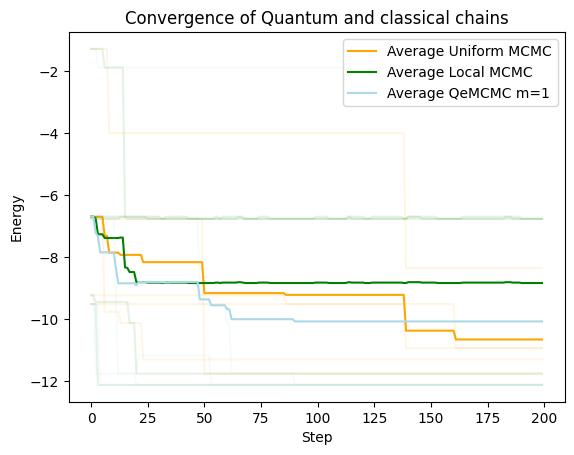

In [10]:
plot_chains(uni_chains, color = 'orange', label="Uniform MCMC")
plot_chains(loc_chains, color = 'green', label="Local MCMC")
plot_chains(qe_chains, color = 'lightblue', label="QeMCMC m=1")
plt.title("Convergence of Quantum and classical chains")
plt.xlabel("Step")
plt.ylabel("Energy")
plt.legend()
plt.show()

# 6. Weighting Hamiltonian terms
Here, the quantum algorithm is not weighing the constraint term any higher than the other terms, but we can change that by changing the couplings weight, and gamma.


In [11]:
m_ = 1 # How many subgroups in (optional) coarse graining
# constrained QeMCMC parameters
gamma = 0.2  # Relative strength of mixer hamiltonian
time = (5,10)  # Time for hamiltonian simulation
steps = 200
coupling_weights_ = np.array([0.1, 0.1, 0.6]) # How much weight each hamiltonian term carries
coupling_weights_ = coupling_weights_/(1-gamma) # Rescale weights to account for gamma taking some of the weight
m_ = 1 # How many subgroups in (optional) coarse graining
def run_qemcmc(rep, m, coupling_weights):
    quantum_proposal = QeProposal(constraint_model, gamma=gamma, time=time, m = m, coupling_weights = coupling_weights)
    return runner.run(quantum_proposal, steps, initial_state=constraint_model.initial_state[rep], name="QeMCMC", verbose=True, sample_frequency=1)

# Run in parallel as they can take a while.
output = Parallel(n_jobs=-1)(delayed(run_qemcmc)(rep, m_, coupling_weights_) for rep in range(reps))
#run_qemcmc(0)

output = np.array(output)
qe_chains_weighted = output[:, 0]
Qe_rejection_weighted = output[:, 1]

# print average rejections per chain
avg_rejections = np.mean(Qe_rejection_weighted)/steps
print(f"Average constraint rejections per step: {avg_rejections}")

Average constraint rejections per step: 0.171


## 6. Results and Visualization

Finally, we plot the energy evolution of the different chains to compare their performance.

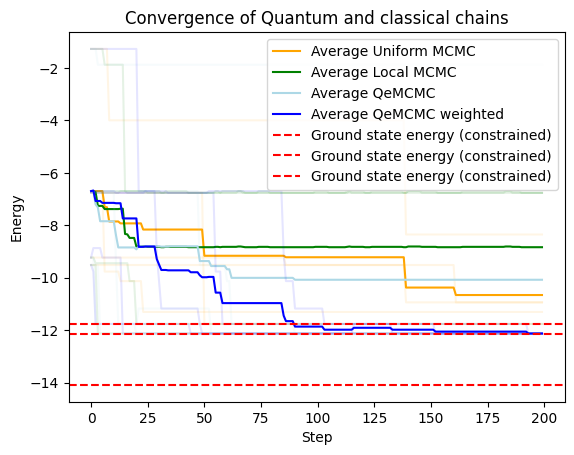

In [12]:
plot_chains(uni_chains, color = 'orange', label="Uniform MCMC")
plot_chains(loc_chains, color = 'green', label="Local MCMC")
plot_chains(qe_chains, color = 'lightblue', label="QeMCMC")
plot_chains(qe_chains_weighted, color = 'blue', label="QeMCMC weighted")

lowest_energies, degeneracies, lowest_configs = constraint_model.get_lowest_energies(100, return_configurations=True)
constrained_lowest_energies = []
for i in range(len(lowest_energies)):
    if degeneracies[i] > 1:
        for j in range(degeneracies[i]):
            if constraint_checker_func(lowest_configs[i][j]):
                constrained_lowest_energies.append(lowest_energies[i])
                #plt.axhline(lowest_energies[i], color="red", linestyle="--", label=f"Ground state energy (degeneracy {degeneracies[i]})")
    else:
        if constraint_checker_func(lowest_configs[i][0]):
            constrained_lowest_energies.append(lowest_energies[i])
            #plt.axhline(lowest_energies[i], color="red", linestyle="--", label="Ground state energy")
for i, energy in enumerate(constrained_lowest_energies):
    if i<3:
        plt.axhline(energy, color="red", linestyle="--", label=f"Low energy state")
plt.title("Convergence of Quantum and classical chains")
plt.xlabel("Step")
plt.ylabel("Energy")
plt.legend()
plt.show()

# Bonus: Coarse graining

As a wee bonus, we include the functionality for doing larger constrained systems, with coarse graining. When the state space is too large, we can use coarse-graining to reduce the number of states. This is done by grouping states together. The MCMC is then run on this smaller, coarse-grained state space.



In [13]:

import numpy as np
from matplotlib import pyplot as plt
from joblib import Parallel, delayed
from scipy import sparse
import itertools

# Internal imports from our QeMCMC package
from qemcmc.sampler import ClassicalProposal, QeProposal
from qemcmc.sampler.runners import MCMCRunner, ConstrainedMCMCRunner
from qemcmc.utils import plot_chains, get_random_state
from qemcmc.model import EnergyModel, ConstraintModel, ModelMaker

In [17]:

# Define a larger system
n_large = 20
steps_large = 10000
reps = 5
temp =0.1
model_large = ModelMaker(n_large, "Fully Connected Ising", "large model").model

shape_of_J = (n_large, n_large)
J_constraint = np.zeros(shape_of_J)
for i in range(n_large):
    for j in range(i+1, n_large):
        u = np.random.uniform(0, 1)
        if u < 0.01:# 10% chance of adding a constraint between these spins
            J_constraint[i, j] = 1
            J_constraint[j, i] = 1


def constraint_checker_func(bitstring: str) -> bool:
    """In {0, 1} representation, this constraint means no two adjacent bits can both be 1"""

    sum = 0
    for i in range(len(bitstring)):
        for j in range(i+1, len(bitstring)):
            if bitstring[i] != bitstring[j]:
                sum += J_constraint[i, j]
    return sum == 0




large_model_constraint = ConstraintModel(n_large, constraint_couplings = [J_constraint,], couplings = model_large.couplings, name="Large Constraint Model", cost_function_signs=model_large.cost_function_signs, constraint_func=constraint_checker_func, constraint_signs = [-1,])  
print("(len(large_model_constraint.initial_state))", len(large_model_constraint.initial_state))

runner_large = ConstrainedMCMCRunner(large_model_constraint, temp, constraint_checker_func)


(len(large_model_constraint.initial_state)) 100


In [18]:
gamma = (0.1,0.3)  # Relative strength of mixer hamiltonian
time = (10, 20)  # Time for hamiltonian simulation
steps_large = 1000


coupling_weights = np.array([0.1, 0.1, 0.5])/(1-np.mean(gamma)) # Rescale weights to account for gamma taking some of the weight

def run_qemcmc_large(rep):
    quantum_proposal = QeProposal(large_model_constraint, gamma=gamma, time=time, m = 3, coupling_weights = coupling_weights)
    return runner_large.run(quantum_proposal, steps_large, initial_state=large_model_constraint.initial_state[rep], name="QeMCMC", verbose=True, sample_frequency=1)

# Run in parallel as they can take a while.
output = Parallel(n_jobs=-1)(delayed(run_qemcmc_large)(rep) for rep in range(reps))
output = np.array(output)
three_large_qe_chains = output[:, 0]
three_large_qe_rejection = output[:, 1]


print("steps large: ", steps_large)
print("rejection counts: ", three_large_qe_rejection)
# print average rejections per chain
avg_rejections = np.mean(three_large_qe_rejection)/steps_large
print(f"Average constraint rejections percent: {100*avg_rejections}")




steps large:  1000
rejection counts:  [73 65 60 67 67]
Average constraint rejections percent: 6.64


In [19]:
gamma = (0.1,0.3)  # Relative strength of mixer hamiltonian
time = (10, 20)  # Time for hamiltonian simulation
steps_large = 1000


coupling_weights = [0.1, 0.1, 0.6]

def run_qemcmc_large(rep):
    quantum_proposal = QeProposal(large_model_constraint, gamma=gamma, time=time, m = 2, coupling_weights = coupling_weights)
    return runner_large.run(quantum_proposal, steps_large, initial_state=large_model_constraint.initial_state[rep], name="QeMCMC", verbose=True, sample_frequency=1)

# Run in parallel as they can take a while.
output = Parallel(n_jobs=-1)(delayed(run_qemcmc_large)(rep) for rep in range(reps))
output = np.array(output)
two_large_qe_chains = output[:, 0]
two_large_qe_rejection = output[:, 1]

# print average rejections per chain
avg_rejections = np.mean(two_large_qe_rejection)/steps_large
print(f"Average constraint rejections percent: {100*avg_rejections}")




Average constraint rejections percent: 7.32


In [20]:
steps_large = 10000

uni_chains_large = []
for rep in range(reps):
    classical_uniform_proposal = ClassicalProposal(model_large, method="uniform")
    uni_chain, uni_rejection = runner_large.run(classical_uniform_proposal, steps_large, initial_state=large_model_constraint.initial_state[rep], name="classical uniform MCMC", verbose=False, sample_frequency=1)
    uni_chains_large.append(uni_chain)
print("uniform constraint rejection percent:", 100 * np.mean(uni_rejection)/steps_large)
loc_chains_large = []
for rep in range(reps):
    classical_local_proposal = ClassicalProposal(model_large, method="2-local")
    loc_chain, loc_rejection = runner_large.run(classical_local_proposal, steps_large, initial_state=large_model_constraint.initial_state[rep], name="classical 2-local MCMC", verbose=False, sample_frequency=1)
    loc_chains_large.append(loc_chain)
print("local constraint rejection percent:", 100 * np.mean(loc_rejection)/steps_large)

uniform constraint rejection percent: 74.41
local constraint rejection percent: 36.38


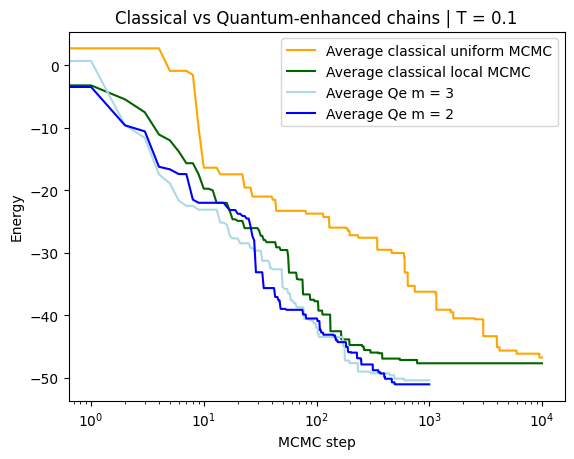

In [21]:
plot_chains(uni_chains_large, "orange", "classical uniform MCMC", plot_individual_chains=False)
plot_chains(loc_chains_large, "darkgreen", "classical local MCMC", plot_individual_chains=False)
plot_chains(three_large_qe_chains, "lightblue", "Qe m = 3", plot_individual_chains=False)
plot_chains(two_large_qe_chains, "blue", "Qe m = 2", plot_individual_chains=False)


plt.xlabel("MCMC step")
plt.ylabel("Energy")
plt.title("Classical vs Quantum-enhanced chains | T = {}".format(temp))
plt.legend()
plt.xscale("log")
plt.show()